# EXPRESSIVE PUNCTUATION PATTERNS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import string
import re
import datasets
import random

C:\Users\jslui\anaconda3\envs\docana\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pre-Processsing
Loading of The Reddit Dataset and Extraction of 30% of training data.

In [2]:
from datasets import load_dataset

tldr = load_dataset("webis/tldr-17", split = 'train[:30%]') # only 30% of data is used to train 

C:\Users\jslui\anaconda3\envs\docana\lib\site-packages\datasets\table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [3]:
# 3 random examples from the Webis-TLDR-17 TIFU dataset:
def show_random_elements(dataset, num_examples=3):
    picks = random.sample(range(len(dataset)), num_examples)
    for i in picks:
        print(dataset[i])
        print("---")

show_random_elements(tldr)

{'author': 'yepthatsme', 'body': "I'm not sure who this guy is, but he seemed frustrated... either way I'm not really sure what the main reason for this blog post is? He seems very staunchly neutral in a way that makes me wonder if he has a point at all...? \n\n\ncan anyone TL:DR this more me, maybe there is a point in the article I missed?", 'normalizedBody': "I'm not sure who this guy is, but he seemed frustrated... either way I'm not really sure what the main reason for this blog post is? He seems very staunchly neutral in a way that makes me wonder if he has a point at all...? \n can anyone TL:DR this more me, maybe there is a point in the article I missed? \n", 'subreddit': 'Bitcoin', 'subreddit_id': 't5_2s3qj', 'id': 'c9ayeer', 'content': "I'm not sure who this guy is, but he seemed frustrated... either way I'm not really sure what the main reason for this blog post is? He seems very staunchly neutral in a way that makes me wonder if he has a point at all...? \n can anyone", 'sum

## Subreddit Selection
Here we find the top 10 subreddits in the data and we sort them in descending order

In [4]:
subreddit_count = {}

for subreddit in tldr['subreddit']:
    subreddit_count[subreddit] = subreddit_count.get(subreddit, 0) + 1

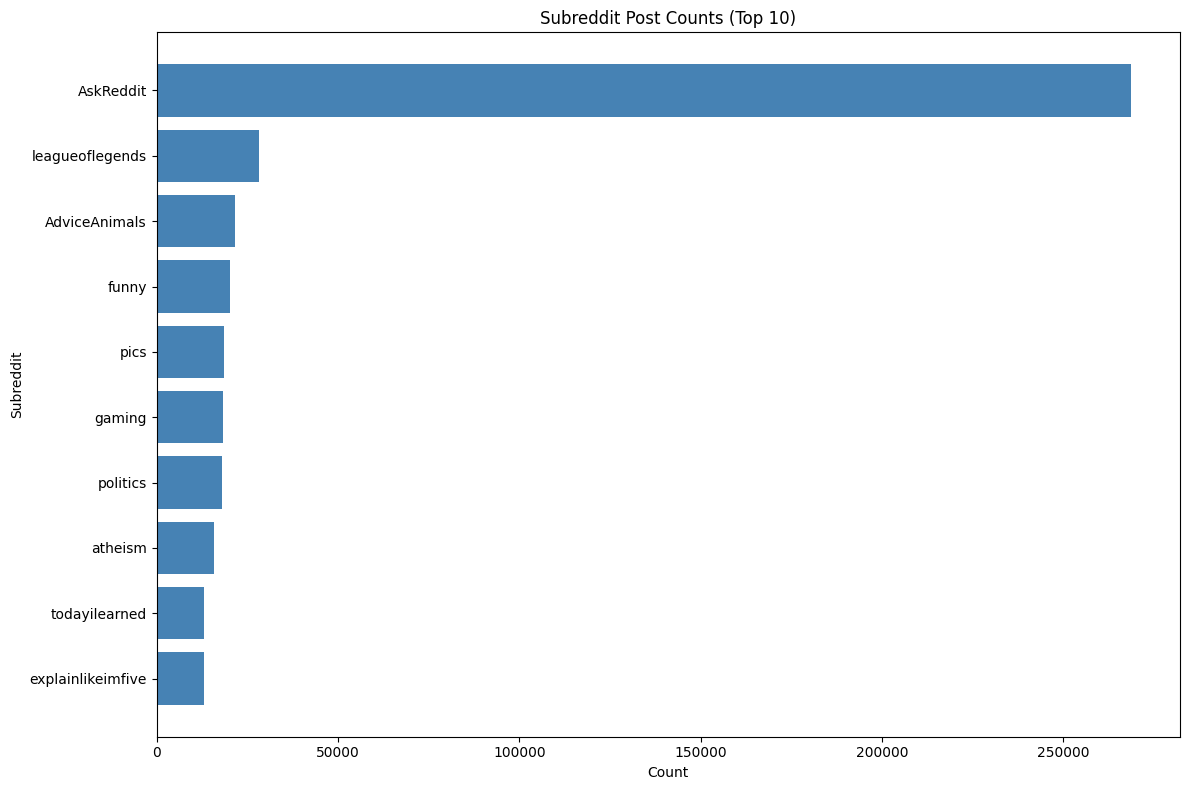

In [5]:
# Sort by count descending and take top 10
subs_10 = sorted(subreddit_count.items(), key=lambda x: x[1], reverse=True)[:10]
subreddits, counts = zip(*subs_10)

plt.figure(figsize=(12, 8))
plt.barh(subreddits, counts, color='steelblue')
plt.xlabel('Count')
plt.ylabel('Subreddit')
plt.title('Subreddit Post Counts (Top 10)')
plt.gca().invert_yaxis()
plt.savefig("../figures/EDA_Top_10_Subreddits.png")
plt.tight_layout()
plt.show()

In [6]:
# subreddits is a tuple of names from the chart above, e.g. ('AskReddit', 'tifu', ...)
top_10_subs = list(subreddits)

# filter dataset to only posts from those top 10 subreddits
dfilt = tldr.filter(lambda x: x['subreddit'] in top_10_subs)
print(top_10_subs)

['AskReddit', 'leagueoflegends', 'AdviceAnimals', 'funny', 'pics', 'gaming', 'politics', 'atheism', 'todayilearned', 'explainlikeimfive']


## Feature Engineering
### Tokenization

In [7]:
def get_tokens(text):
    return nltk.word_tokenize(text)

def get_sentences(text):
    return nltk.sent_tokenize(text)

### Special Punctuation Expressions
Modern vernacular includes certain chains of punctuations that can be used to express different ranges of emotions
- ...  =>  pause or unfinished though
- ???? => extreme confusion
- !!!!!=> intense feelings of happiness/ anger
- ?!?! => interrobang
- !?!? => interrobang
- ---- => intentional pause

In [8]:
EXPRESSIVE_PATTERNS = {
    "ELLIPSIS": r"\.{3,}",       # ..., ...., .....
    "MULTI_QUEST": r"\?{2,}",        # ??, ???, ?????
    "MULTI_EXCL": r"!{2,}",         # !!, !!!, !!!!!!
    "QUEST-EXCL": r"(?:\?!){2,}",       # ?!?!, ?!?!?! ...
    "EXCL-QUEST": r"(?:!\?){2,}",       # !?!?, !?!?!? ...
    "DOUBLE_DASH": r"--+"       #------,
}

### Punctuation Count
We use 1500 as max number of posts to reduce the runtime.\
Tokenization splits text into words and punctuation marks, then filters out only punctuation tokens for analysis

In [9]:
from collections import Counter

max_posts=1500
def get_punctuation_counts(subreddit):
    punctuation = []
    expressive = Counter()

    count = 0
    for row in dfilt:
        if row['subreddit'] != subreddit:
            continue

        text = str(row['content'])

        # count expressive punctuation
        for name, pattern in EXPRESSIVE_PATTERNS.items():
            expressive[name] += len(re.findall(pattern, text))

        #Tokenization 
        tokens = get_tokens(text)
        punctuation.extend([t for t in tokens if t in string.punctuation])

        count += 1
        if count >= max_posts:
            break

    return Counter(punctuation) + expressive

### Average sentence length
$$=\frac{Total\ no.\ of\ words}{Total\ no.\ of\ sentences}$$

In [10]:
def get_avg_sentence_length(subreddit):
    total_words = 0
    total_sentences = 0
    count = 0
    for row in dfilt:
        if row['subreddit'] != subreddit:
            continue
        text = str(row['content'])
        sentences = get_sentences(text)
        for sent in sentences:
            sent_tokens = get_tokens(sent)
            words = [t for t in sent_tokens if t not in string.punctuation]
            total_words += len(words)
            total_sentences += 1
        count += 1
        if count >= max_posts:
            break
    return (total_words / total_sentences) if total_sentences > 0 else 0.0


### Average words between punctuation
$$=\frac{Total\ words\ between\ punctuation\ marks}{Total\ no.\ of\ intervals}$$

In [11]:
def get_avg_words_between_punct(subreddit):
    total_intervals = 0
    total_words = 0
    count = 0
    for row in dfilt:
        if row['subreddit'] != subreddit:
            continue
        text = str(row['content'])
        tokens = get_tokens(text)
        words_since_punct = 0
        for token in tokens:
            if token in string.punctuation:
                total_intervals += 1
                total_words += words_since_punct
                words_since_punct = 0
            else:
                words_since_punct += 1
        count += 1
        if count >= max_posts:
            break
    return (total_words / total_intervals) if total_intervals > 0 else 0.0

### Printing & Saving Results

In [12]:
# Loop through subreddits and print results
results = []
for sub in top_10_subs:
    punct_counts = get_punctuation_counts(sub)
    avg_sent_len = get_avg_sentence_length(sub)
    avg_words_punct = get_avg_words_between_punct(sub)
    results.append({
        "subreddit": sub,
        "punctuation_counts": punct_counts,
        "avg_sentence_length": avg_sent_len,
        "avg_words_between_punct": avg_words_punct
    })
    print(f"\n\nr/{sub}")
    print("-" * 150)
    print("punctuation_counts:", punct_counts)
    print("avg_sentence_length:",avg_sent_len)
    print("avg_words_between_punct:", avg_words_punct)



r/AskReddit
------------------------------------------------------------------------------------------------------------------------------------------------------
punctuation_counts: Counter({'.': 17313, ',': 14464, '(': 1652, ')': 1604, '?': 733, 'ELLIPSIS': 633, '!': 625, ':': 553, '-': 305, "'": 271, ';': 162, '$': 154, '[': 110, '%': 108, ']': 108, '>': 94, 'MULTI_EXCL': 57, 'DOUBLE_DASH': 56, '&': 42, '*': 41, '#': 20, '/': 18, 'MULTI_QUEST': 17, '+': 11, '=': 9, '<': 6, '@': 4, 'QUEST-EXCL': 4, '{': 3, '}': 3, '~': 2, 'EXCL-QUEST': 2, '|': 1, '^': 1, '\\': 1})
avg_sentence_length: 17.8302188148858
avg_words_between_punct: 8.688531417564683


r/leagueoflegends
------------------------------------------------------------------------------------------------------------------------------------------------------
punctuation_counts: Counter({'.': 11273, ',': 10282, ')': 1590, '(': 1584, '?': 661, ':': 577, '%': 364, 'ELLIPSIS': 281, '-': 278, '>': 230, '!': 223, ';': 166, ']': 158, '

### Visualization
For conversion of counts to percentages, $e^{-9}$ is added to prevent division by zero i.e when a subreddit has no punctuation.

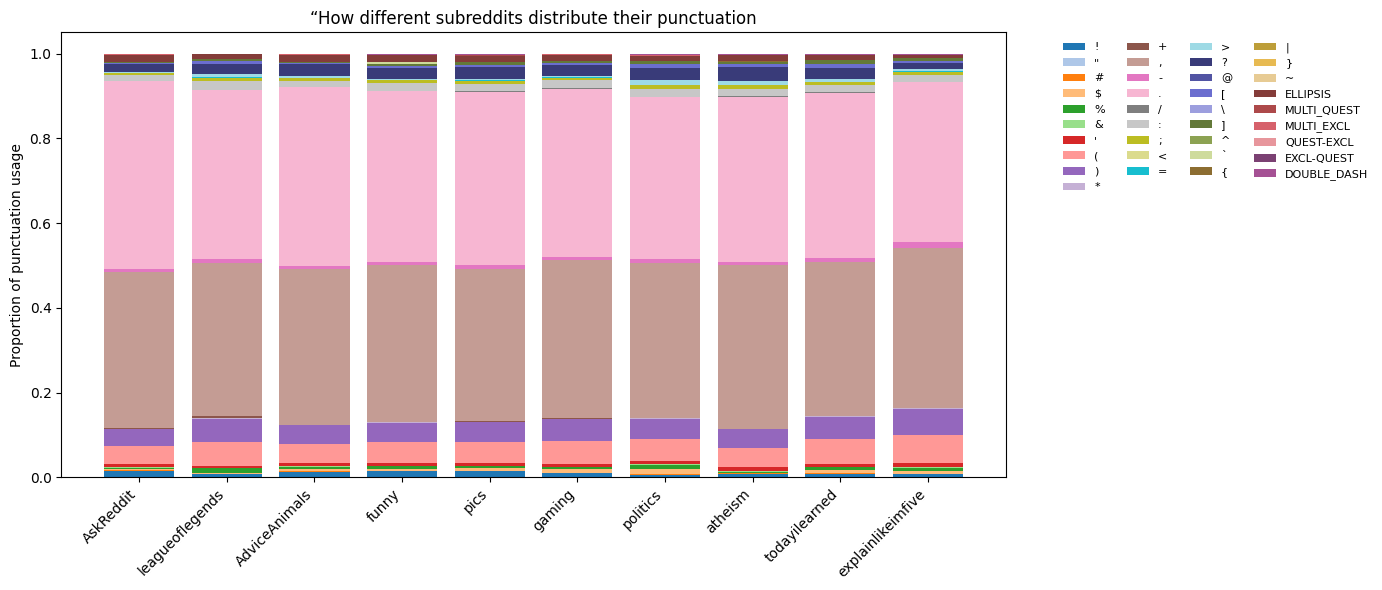

In [13]:
features = list(string.punctuation) + list(EXPRESSIVE_PATTERNS.keys()) #use normal punctuations and expressive patterns
labels = top_10_subs
matrix = []

for sub in labels:
    counts = get_punctuation_counts(sub)
    matrix.append([counts.get(f, 0) for f in features])

matrix = np.array(matrix)

row_sums = matrix.sum(axis=1, keepdims=True)
#converts counts to percentages
norm_matrix = matrix / (row_sums + 1e-9)

#Includes contrasting colours
colors = (
    list(plt.cm.tab20.colors) +
    list(plt.cm.tab20b.colors) +
    list(plt.cm.tab20c.colors)
)

#according to the number of features
colors = colors[:len(features)]

plt.figure(figsize=(14,6))

bottom = np.zeros(len(labels))

for i, feat in enumerate(features):
    plt.bar(
        labels,
        norm_matrix[:, i],
        bottom=bottom,
        color=colors[i],
        label=feat
    )
    bottom += norm_matrix[:, i]

plt.xticks(rotation=45, ha='right')
plt.ylabel("Proportion of punctuation usage")
plt.title("“How different subreddits distribute their punctuation")

plt.legend(
    ncol=4,
    fontsize=8,
    bbox_to_anchor=(1.05, 1),
    frameon=False
)
plt.savefig("../figures/EDA_Punctuation_Distribution.png")
plt.tight_layout()
plt.show()

## Classification
A classifier is used to predict the subreddit based on punctuation.

### Frequency per 100 words
We calculate the punctuation frequency per 100 words for 1000 posts in groups of 20 for each of the 10 subreddits we chose. Then turn that into a csv file.

In [14]:
# SETTINGS
MAX_POSTS_PER_SUB = 1000
GROUP_SIZE = 20

PUNCT_LIST = list(string.punctuation)

# FEATURE EXTRACTION
def extract_punct_features(text):

    #Tokenization
    tokens = get_tokens(text)

    #Word Counting
    words = [t for t in tokens if t not in string.punctuation]
    n_words = len(words)

    #Handle empty text
    if n_words == 0:
        feats = {p: 0.0 for p in PUNCT_LIST}
        for k in EXPRESSIVE_PATTERNS:
            feats[k] = 0.0
        return feats

    #Punctuation counter
    counts = Counter(t for t in tokens if t in string.punctuation)

    #Normalization of punctuation per word
    feats = {
        p: (counts.get(p, 0) / n_words) * 100
        for p in PUNCT_LIST
    }

    # expressive punctuation frequencies per 100 words
    for name, pattern in EXPRESSIVE_PATTERNS.items():
        feats[name] = (
            len(re.findall(pattern, text)) / n_words
        ) * 100

    return feats

# BUILD CSV DATASET
rows = []

for sub in top_10_subs:

    subreddit_posts = []

    # collect up to 500 posts
    for row in dfilt:

        if row["subreddit"] != sub:
            continue

        subreddit_posts.append(str(row["content"]))

        if len(subreddit_posts) >= MAX_POSTS_PER_SUB:
            break

    # create groups of 20 posts
    for i in range(0, len(subreddit_posts), GROUP_SIZE):

        chunk = subreddit_posts[i:i + GROUP_SIZE]

        if len(chunk) < GROUP_SIZE:
            continue

        combined_text = " ".join(chunk)

        feats = extract_punct_features(combined_text)

        feats["subreddit"] = sub
        feats["group_id"] = i // GROUP_SIZE

        rows.append(feats)

# dataframe
punct_df = pd.DataFrame(rows)

# subreddit first
cols = (
    ["subreddit", "group_id"] +
    [c for c in punct_df.columns
     if c not in ["subreddit", "group_id"]]
)

punct_df = punct_df[cols]

# save
punct_df.to_csv("../figures/punctuation_features.csv", index=False)

print("Rows:", len(punct_df))
print("Rows per subreddit:", MAX_POSTS_PER_SUB // GROUP_SIZE)
print(punct_df.head())

Rows: 500
Rows per subreddit: 50
   subreddit  group_id         !    "    #    $         %         &         '  \
0  AskReddit         0  0.184313  0.0  0.0  0.0  0.020479  0.000000  0.040958   
1  AskReddit         1  0.324394  0.0  0.0  0.0  0.000000  0.000000  0.064879   
2  AskReddit         2  0.000000  0.0  0.0  0.0  0.000000  0.031417  0.031417   
3  AskReddit         3  0.480000  0.0  0.0  0.0  0.000000  0.000000  0.128000   
4  AskReddit         4  0.088515  0.0  0.0  0.0  0.000000  0.000000  0.154902   

          (  ...      {    |      }    ~  ELLIPSIS  MULTI_QUEST  MULTI_EXCL  \
0  0.471022  ...  0.000  0.0  0.000  0.0  0.122875     0.000000    0.020479   
1  0.497405  ...  0.000  0.0  0.000  0.0  0.216263     0.000000    0.021626   
2  0.691172  ...  0.000  0.0  0.000  0.0  0.219918     0.188501    0.000000   
3  0.640000  ...  0.032  0.0  0.032  0.0  0.192000     0.000000    0.064000   
4  0.575349  ...  0.000  0.0  0.000  0.0  0.132773     0.000000    0.000000   

   QU

### Classifiers and Scores
We use 2 kinds of classifier to determine if linear separation plays a role.\
Each model studies to find correlation between the punctuation and the subreddit.

#### 1. Random Forest Classifier
Here, the guesses of the 200 trees(n_estimator) is then averaged during prediction. Random Forest Classifier learns the rules and takes a majority vote from the different trees.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = punct_df.drop(columns=['subreddit'])
y = punct_df['subreddit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

#HEADER FORMATTING
print("\033[1;35m")  # bold magenta
print("╔" + "═"*40 + "╗")
print("║      CLASSIFICATION REPORT".center(40) + "║")
print("╚" + "═"*40 + "╝")
print("\033[0m")  # reset

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


╔════════════════════════════════════════╗
      ║      CLASSIFICATION REPORT      ║
╚════════════════════════════════════════╝

Accuracy: 0.41333333333333333
                   precision    recall  f1-score   support

    AdviceAnimals       0.23      0.20      0.21        15
        AskReddit       0.30      0.40      0.34        15
          atheism       0.53      0.67      0.59        15
explainlikeimfive       0.53      0.67      0.59        15
            funny       0.36      0.33      0.34        15
           gaming       0.56      0.33      0.42        15
  leagueoflegends       0.53      0.67      0.59        15
             pics       0.20      0.07      0.10        15
         politics       0.44      0.73      0.55        15
    todayilearned       0.14      0.07      0.09        15

         accuracy                           0.41       150
        macro avg       0.38      0.41      0.38       150
     weighted avg       0.38      0.41      0.38       150



#### 2. LinearSVC
LinearSVC assumes that subreddits can be separated by relatively simple linear relationships between punctuation features.

In [16]:
from sklearn.svm import LinearSVC

clf = LinearSVC(
    random_state=42,
    max_iter=5000
)

clf.fit(X_train, y_train)

svc_pred = clf.predict(X_test)

print("\033[1;35m")  # bold magenta
print("╔" + "═"*40 + "╗")
print("║      CLASSIFICATION REPORT".center(40) + "║")
print("╚" + "═"*40 + "╝")
print("\033[0m")  # reset
print("Accuracy:", accuracy_score(y_test, svc_pred))
print(classification_report(y_test, svc_pred))


╔════════════════════════════════════════╗
      ║      CLASSIFICATION REPORT      ║
╚════════════════════════════════════════╝

Accuracy: 0.38
                   precision    recall  f1-score   support

    AdviceAnimals       0.33      0.07      0.11        15
        AskReddit       0.34      0.67      0.45        15
          atheism       0.38      0.60      0.46        15
explainlikeimfive       0.48      0.73      0.58        15
            funny       0.24      0.27      0.25        15
           gaming       0.50      0.27      0.35        15
  leagueoflegends       0.41      0.60      0.49        15
             pics       0.00      0.00      0.00        15
         politics       0.47      0.60      0.53        15
    todayilearned       0.00      0.00      0.00        15

         accuracy                           0.38       150
        macro avg       0.31      0.38      0.32       150
     weighted avg       0.31      0.38      0.32       150



#### CONCLUSION:
A higher accuracy was achieved with Random Forest Classifier suggesting that punctuation features are not completely linearly separable.

### Visualization
We only consider the results from Random Forest Classification for visualization

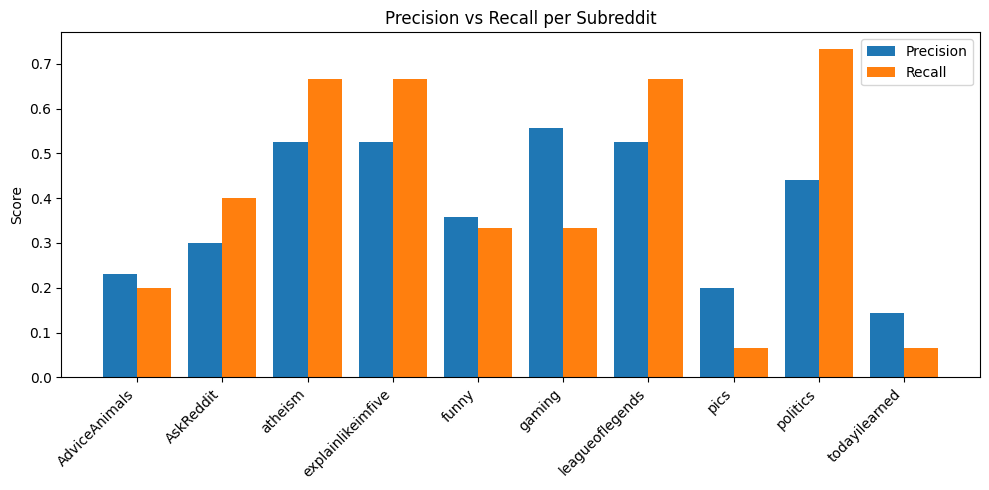

In [17]:
report = classification_report(y_test, rf_pred, output_dict=True)

classes = list(report.keys())[:-3]  # ignore avg rows

precision = [report[c]['precision'] for c in classes]
recall = [report[c]['recall'] for c in classes]

x = range(len(classes))

plt.figure(figsize=(10,5))
plt.bar(x, precision, width=0.4, label="Precision")
plt.bar([i+0.4 for i in x], recall, width=0.4, label="Recall")

plt.xticks([i+0.2 for i in x], classes, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Precision vs Recall per Subreddit")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/EDA_Precision_Recall.png")
plt.show()

High precision and recall (athesim, explainlikeimfive, leagueoflegends, politics) indicate consistent punctuation patterns.
whereas for low precision and recall (pics,funny, todayilearned) indicate no strong distinguishing feature.

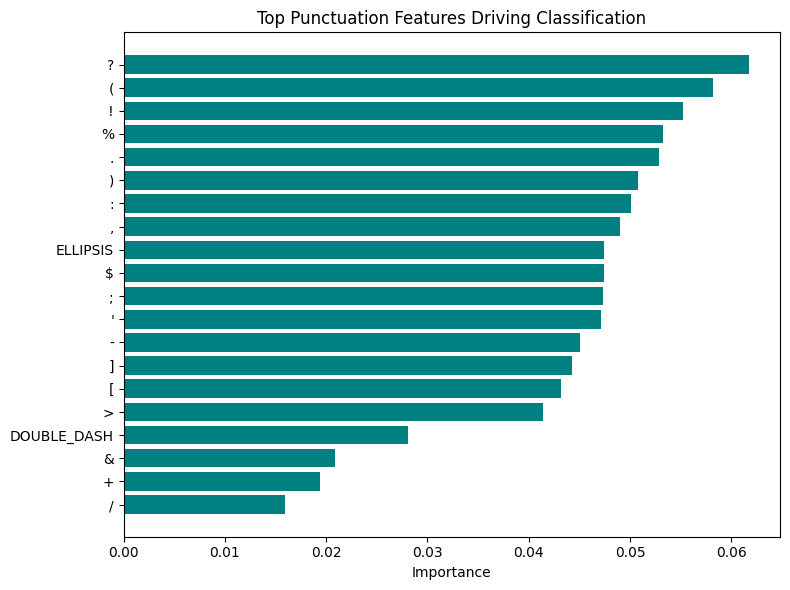

In [18]:
importances = rf.feature_importances_
# remove group_id 
mask = X.columns != "group_id"
features = X.columns[mask]
importances = importances[mask]


idx = np.argsort(importances)[-20:]  # top 20 features

plt.figure(figsize=(8, 6))
plt.barh(features[idx], importances[idx], color="teal")

plt.title("Top Punctuation Features Driving Classification")
plt.xlabel("Importance")

plt.tight_layout()
plt.savefig("../figures/EDA_Top_Punct_Features.png")
plt.show()